# **IMPLÉMENTATION DU MODÈLE CNN-RNN POUR LA PRÉDICTION DU MOUVEMENT DE LA MAIN SUR DES VIDÉOS**

## **1. Constitution du Dataset**

Le jeu de données de ce projet est composé de vidéos enregistrées en haute définition. Pour que le modèle soit capable de reconnaître les gestes de n'importe qui, nous avons filmé des hommes, des femmes et des enfants avec une tranche d'âge assez large, allant de **8 à 60 ans**. Chaque vidéo montre une personne qui compte avec ses doigts de 0 à 5, en suivant un ordre précis et progressif. Toutes les prises de vue ont été faites sur un fond blanc uni et avec un bon éclairage. Ce choix est important car il permet de supprimer les éléments inutiles autour de la main (le bruit visuel) et aide le modèle à mieux se concentrer sur la forme et la position des doigts.

## **2. Préparation des données**
Pour le prétraitement, nous avons transformé les vidéos en une série d'images pour qu'elles soient exploitables par nos modèles. Nous avons choisi de découper les séquences à un rythme de 5 images par seconde (5 FPS). Sur les 136 dossiers de départ, nous en avons gardé 115 après avoir écarté ceux qui présentaient des défauts de qualité ou des gestes saccadés. Au final, cela nous donne une base de données solide de 3 869 images pour l'entraînement et les tests. Ils ont été renommés selon la notation suivante :               num-seconde_num-image_classe avec classe compris entre 0 et 5.


## **3. Structure du modèle**
Concernant l'architecture, nous utilisons un modèle hybride qui mélange vision par ordinateur et analyse du temps. Pour analyser l'image et reconnaître les formes, nous avons choisi MobileNetV2, car c'est un modèle léger et très efficace pour extraire les caractéristiques importantes de la main. Ensuite, pour comprendre l'enchaînement des mouvements et prédire le geste suivant, nous avons ajouté un réseau GRU (Gated Recurrent Unit). Ce dernier permet de mémoriser la suite des images pour anticiper avec précision l'évolution du comptage.

# **I - ENTRAINEMENT DU MODÈLE CNN**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Les étiquettes sont extraites directement du nom des fichiers. Enfin, nous avons divisé les données en trois groupes distincts : 70 % pour l'entraînement, 15 % pour la validation et 15 % pour les tests finaux. Cette répartition est faite de manière "stratifiée", ce qui garantit que chaque groupe contient la même proportion de gestes (de 0 à 5) pour un apprentissage équilibré.

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

def prepare_data_index(data_path):
    file_paths = []
    labels = []

    if not os.path.exists(data_path):
        print(f"Erreur : Le chemin {data_path} n'existe pas.")
        return None

    print("Indexation des fichiers en cours...")

    for video_dir in os.listdir(data_path):
        path = os.path.join(data_path, video_dir)
        if not os.path.isdir(path): continue

        for img_name in os.listdir(path):
            if img_name.endswith('.jpg'):
                try:
                    # Extraction du label (on le garde en string pour le générateur)
                    label = img_name.split('_')[-1].split('.')[0]
                    clean_label = label.strip()[0]
                    file_paths.append(os.path.join(path, img_name))
                    labels.append(clean_label)
                except:
                    continue

    return pd.DataFrame({'filename': file_paths, 'label': labels})


path_drive = '/content/drive/MyDrive/dataset_final2'
df = prepare_data_index(path_drive)


counts = df['label'].value_counts()
print("Répartition des images par classe :")
print(counts)

#Identification des classes qui ont au moins 2 images
classes_valides = counts[counts >= 2].index

#Filtrage du DataFrame pour ne garder que ces classes
df_filtre = df[df['label'].isin(classes_valides)].copy()

print(f"\nImages initiales : {len(df)}")
print(f"Images après filtrage : {len(df_filtre)}")


train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['label']
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['label']
)

print(f"Total images : {len(df)}")
print(f"Entraînement (Train) : {len(train_df)} images")
print(f"Validation (Valid)   : {len(valid_df)} images")
print(f"Test (Test)          : {len(test_df)} images")

Indexation des fichiers en cours...
Répartition des images par classe :
label
2    686
3    678
1    673
5    582
4    566
0    504
Name: count, dtype: int64

Images initiales : 3689
Images après filtrage : 3689
Total images : 3689
Entraînement (Train) : 2582 images
Validation (Valid)   : 553 images
Test (Test)          : 554 images


### **1) - Prétraitement du dataset**

Pour charger et préparer les images avant leur passage dans le modèle, nous avons utilisé l'outil **ImageDataGenerator** de TensorFlow. Ce processus permet d'automatiser la normalisation des pixels (en ramenant les valeurs entre 0 et 1), et le redimensionnement automatique de toutes les photos au format $224 \times 224$ pixels pour correspondre aux exigences de **MobileNetV2**. Les données sont envoyées par groupes de 32 (batchs). Nous avons activé le mélange des données (shuffle) uniquement pour l'entraînement afin que le modèle ne dépende pas de l'ordre des fichiers.

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Générateur d'Entrainement
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

# 2. Générateur de Validation
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# 3. Générateur de Test
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

Found 2582 validated image filenames belonging to 6 classes.
Found 553 validated image filenames belonging to 6 classes.
Found 554 validated image filenames belonging to 6 classes.


### **2) - Entrainement du modèle par apprentissage par transfert**

Pour la phase d'apprentissage, nous avons construit un modèle basé sur **MobileNetV2**, un réseau déjà pré-entraîné sur des millions d'images (ImageNet). Dans un premier temps, nous avons gelé ses couches pour conserver ses capacités de reconnaissance de formes de base. Par-dessus, nous avons ajouté une structure personnalisée : **une couche de réduction (Pooling), une couche de calcul intermédiaire (Dense)** pour affiner les caractéristiques, et nous avons opté pour la **BatchNormalization** et le **Dropout** pour stabiliser l'entraînement et éviter que le modèle n'apprenne par cœur les images (surapprentissage). Enfin, nous avons compilé le modèle avec un taux d'apprentissage lent et stable, puis lancé l'entraînement sur **20** époques pour permettre au réseau de bien s'adapter aux gestes de comptage.

In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import numpy as np
import tensorflow as tf

NUM_CLASSES = 6

# 1. Charger MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 2. Architecture
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu', name='feature_layer'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 3. Compilation avec un Learning Rate stable
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Entraînement
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=20
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.2916 - loss: 1.9900 - val_accuracy: 0.4521 - val_loss: 1.4109
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.4915 - loss: 1.3133 - val_accuracy: 0.5841 - val_loss: 1.1185
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.5840 - loss: 1.0779 - val_accuracy: 0.6456 - val_loss: 0.9462
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.6352 - loss: 0.9688 - val_accuracy: 0.6781 - val_loss: 0.8504
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6816 - loss: 0.8279 - val_accuracy: 0.7089 - val_loss: 0.7701
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.7173 - loss: 0.7354 - val_accuracy: 0.7161 - val_loss: 0.7163
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7560 - loss: 0.6469 - val_accuracy: 0.7523 - val_loss: 0.6660
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7750 - loss: 0.6103 - val_accuracy: 0.7667 - v

Les performances obtenues en fin d'entraînement montrent une **précision globale** de **92,18 %** sur les *données d'apprentissage* et de **87,34 %** sur les *données de validation*. Cet écart modéré entre les deux scores, ainsi que la valeur de la perte de validation **($0,39$)**, indiquent que le modèle a bien appris à reconnaître les gestes de comptage tout en conservant une bonne capacité de généralisation. Le modèle ne se contente pas de mémoriser les images, il parvient à identifier les caractéristiques réelles des doigts sur de nouveaux sujets.

Ces résultats valident l'efficacité de l'extracteur de caractéristiques **MobileNetV2** pour cette tâche de reconnaissance gestuelle.

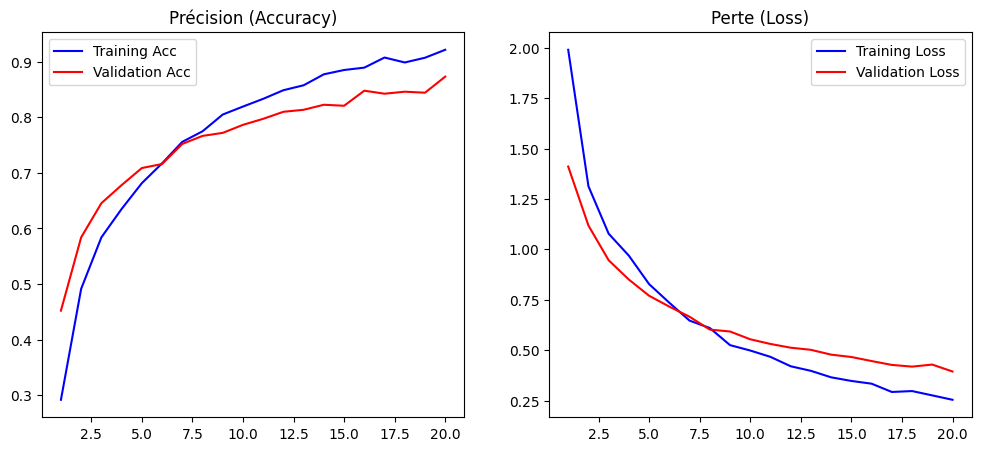

In [6]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Graphe de l'Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Précision (Accuracy)')
    plt.legend()

    # Graphe de la Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Perte (Loss)')
    plt.legend()

    plt.show()

plot_history(history)

Les courbes d'apprentissage permettent de visualiser l'évolution des performances du modèle tout au long des 20 époques. La courbe de loss montre une diminution progressive de l'erreur, ce qui prouve que le réseau optimise efficacement ses poids pour reconnaître les gestes. De son côté, la remontée ou la stabilisation de la val_accuracy autour de 87 % confirme que le modèle généralise bien sur de nouveaux sujets sans trop apprendre par cœur.

### **3) - Sauvegarde du modèle**

In [7]:
loss, acc = model.evaluate(test_generator)
print(f"Précision finale : {acc:.2f}")

# Sauvegarder le meilleur modèle
model.save('best_classifier.h5')

18/18 ━━━━━━━━━━━━━━━━━━━━ 106s 6s/step - accuracy: 0.8881 - loss: 0.3638


Précision finale : 0.89


La prédiction sur les données de test est de **89%**

### **4) - Évaluation du modèle**

Évaluation sur le jeu de test...
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

    Classe 0       0.95      0.93      0.94        75
    Classe 1       0.94      0.90      0.92       101
    Classe 2       0.89      0.92      0.90       103
    Classe 3       0.85      0.86      0.85       102
    Classe 4       0.80      0.84      0.82        85
    Classe 5       0.93      0.88      0.90        88

    accuracy                           0.89       554
   macro avg       0.89      0.89      0.89       554
weighted avg       0.89      0.89      0.89       554



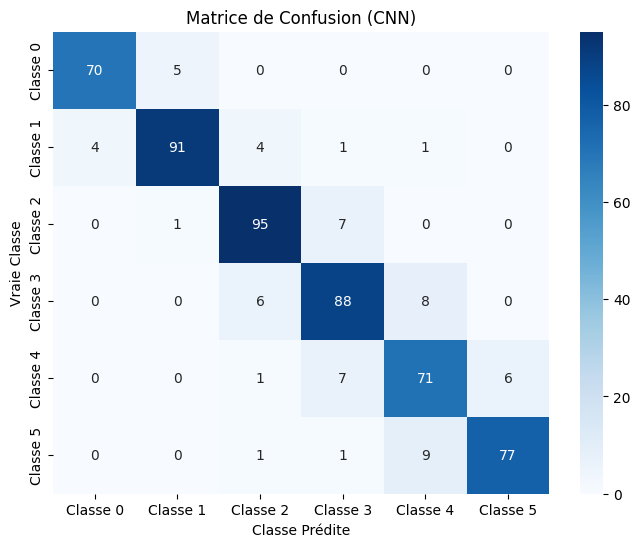

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print("Évaluation sur le jeu de test...")
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

target_names = [f"Classe {i}" for i in range(NUM_CLASSES)]
print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_true, y_pred, target_names=target_names))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Matrice de Confusion (CNN)')
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.show()

Le rapport de classification confirme la solidité du modèle avec une précision moyenne (accuracy) de **89 %** sur l'ensemble de **test**. On remarque que le modèle est particulièrement performant sur les classes extrêmes comme le **0 (F1-score de 0,94)** et le **1 (0,92)**, ce qui s'explique par la forme très distinctive de ces gestes. En revanche, les scores sont légèrement plus bas pour les classes 3 et 4, car la position des doigts pour ces chiffres est souvent plus complexe à différencier visuellement. Globalement, l'équilibre entre la précision et le rappel (F1-score proche de **0,90** pour la majorité des classes) prouve que le modèle est fiable et prêt à fournir des données de qualité au modèle GRU pour l'analyse temporelle.

# **II - ENTRAINEMENT DU MODÈLE GRU**

### **1) - Prétraitement du dataset par individus**

Cette méthode de découpage par sujets est indispensable pour garantir l'intégrité de l'analyse temporelle. En regroupant les images par identifiant de séquence (seq_id), nous nous assurons que le modèle respecte l'ordre chronologique des gestes pour chaque personne précise. Cela permet au GRU d'apprendre la dynamique réelle du comptage — par exemple, le passage fluide du chiffre 2 au chiffre 3 — sans mélanger les styles d'exécution de différents individus. Cette structure prépare ainsi les données sous forme de séries temporelles cohérentes, ce qui est la condition nécessaire pour que le réseau récurrent puisse prédire avec précision la représentation de l'image suivante.

In [9]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

def prepare_final_split(base_path):
    subjects = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    # Split 70% Train, 15% Valid, 15% Test
    train_subs, temp_subs = train_test_split(subjects, train_size=0.7, random_state=42)
    val_subs, test_subs = train_test_split(temp_subs, train_size=0.5, random_state=42)

    def build_df(sub_list):
        data = []
        for sub in sub_list:
            sub_path = os.path.join(base_path, sub)
            for img in os.listdir(sub_path):
                if img.endswith('.jpg'):
                    parts = img.split('_')
                    data.append({
                        'filename': os.path.join(sub_path, img),
                        'subject': sub,
                        'second': parts[0],
                        'label': int(parts[-1].split('.')[0]),
                        'seq_id': f"{sub}_{parts[0]}"
                    })
        return pd.DataFrame(data)

    return build_df(train_subs), build_df(val_subs), build_df(test_subs)

path_drive = '/content/drive/MyDrive/dataset_final2'
train_df, val_df, test_df = prepare_final_split(path_drive)

print(f"Train: {len(train_df)} images | Valid: {len(valid_df)} | Test: {len(test_df)}")

Train: 2581 images | Valid: 553 | Test: 567


Cette étape consiste à transformer notre classifieur en un extracteur de caractéristiques (feature extractor) spécialisé. Plutôt que d'utiliser la sortie finale du modèle (les probabilités de 0 à 5), nous isolons la couche feature_layer qui contient une représentation mathématique condensée de l'image (un vecteur de 256 valeurs). Ce vecteur capture l'essence visuelle de la position de la main. En gelant cet extracteur, nous nous assurons que les caractéristiques spatiales apprises par MobileNetV2 restent stables, fournissant ainsi une base solide et fiable pour que le modèle GRU puisse se concentrer uniquement sur l'apprentissage de la dynamique temporelle et de l'enchaînement des gestes.

In [10]:
import tensorflow as tf
import os
import numpy as np
import cv2
from tensorflow.keras import layers, models


IMG_SIZE = (224, 224)

# 1. Chargement du modèle complet
full_model = tf.keras.models.load_model('best_classifier.h5')
dummy_input_for_build = tf.zeros((1, *IMG_SIZE, 3))
_ = full_model(dummy_input_for_build)

# 2. Création de l'extracteur : Entrée du CNN -> Sortie de la couche
new_input_tensor = tf.keras.Input(shape=(*IMG_SIZE, 3))

x = full_model.layers[0](new_input_tensor) # MobileNetV2 base
x = full_model.layers[1](x)               # GlobalAveragePooling2D
output_features = full_model.layers[2](x) # La couche 'feature_layer(Dense(256))

feature_extractor = models.Model(inputs=new_input_tensor, outputs=output_features)

# On gèle l'extracteur, il ne sera plus entraîné
feature_extractor.trainable = False

print("Feature extractor created successfully with robust method.")
print(f"Output shape of feature extractor: {feature_extractor.output_shape}")

Feature extractor created successfully with robust method.
Output shape of feature extractor: (None, 256)


Afin de maximiser l'exploitation de notre jeu de données, nous avons implémenté une stratégie de fenêtre glissante (sliding window) pour l'extraction des séquences temporelles en parcourant l'intégralité des images d'un sujet en créant des sous-séquences décalées d'une trame à chaque étape. Concrètement, pour chaque groupe d'images, nous prélevons un bloc de quatre images consécutives servant de contexte historique, dont les caractéristiques spatiales ont été extraites par notre CNN, pour prédire la représentation latente de la cinquième image suivante. Cette méthode permet de multiplier considérablement le volume d'exemples d'entraînement, tout en forçant le modèle GRU à capturer la dynamique du mouvement gestuel à différents stades de son exécution, garantissant ainsi une meilleure robustesse lors de la phase de prédiction.

In [11]:
import re

def natural_keys(text):
    return [int(c) for c in re.split(r'(\d+)', text) if c.isdigit()]

def prepare_sequences_5fps(df, feature_extractor):
    X, Y_feat, Y_lab = [], [], []

    for seq_id, group in df.groupby('seq_id'):
        group = group.sort_values(by='filename', key=lambda x: x.map(natural_keys))

        if len(group) < 5: continue

        # Fenêtre glissante : on parcourt toute la séquence
        for i in range(len(group) - 4):
            paths = group['filename'].values[i : i+5]
            labels = group['label'].values[i : i+5]

            # Prétraitement et Extraction
            imgs = [cv2.resize(cv2.imread(p), (224, 224)) / 255.0 for p in paths]
            latents = feature_extractor.predict(np.array(imgs), verbose=0)

            # SEQUENCE : 4 images d'entrée -> 1 image cible
            X.append(latents[0:4])
            Y_feat.append(latents[4])
            Y_lab.append(labels[4])

    return np.array(X), np.array(Y_feat), np.array(Y_lab)

X_train, Y_train_f, Y_train_l = prepare_sequences_5fps(train_df, feature_extractor)
X_val, Y_val_f, Y_val_l = prepare_sequences_5fps(val_df, feature_extractor)
X_test, Y_test_f, Y_test_l = prepare_sequences_5fps(test_df, feature_extractor)

### **2) - Entrainement du modèle GRU**

Nous avons opté pour l'erreur quadratique moyenne (MSE) comme fonction de perte, nous entraînons le réseau à anticiper avec précision la "signature visuelle" du futur mouvement, créant ainsi un pont entre la reconnaissance d'image statique et la compréhension de l'action dans le temps.

In [12]:
from tensorflow.keras import layers, models

latent_dim = 256

model_prediction = models.Sequential([
    layers.Input(shape=(5, latent_dim)),
    layers.GRU(512, return_sequences=True),
    layers.GRU(256, return_sequences=False, name='gru_latent_output'),
    layers.Dense(512, activation='relu'),
    layers.Dense(latent_dim, activation='linear')
])


model_prediction.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_prediction.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 5, 512)         │     1,182,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_latent_output (GRU)         │ (None, 256)            │       591,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,036,992 (7.77 MB)

 Trainable params: 2,036,992 (7.77 MB)

 Non-trainable params: 0 (0.00 B)

Pour optimiser l'apprentissage et garantir la stabilité, nous avons utilisé les **callbacks**. Le **ReduceLROnPlatea**u permet d'ajuster dynamiquement la vitesse d'apprentissage. Parallèlement, l'**EarlyStopping** agit comme une sécurité contre le surapprentissage (overfitting) en interrompant l'entraînement si la performance sur les données de validation ne s'améliore plus pendant 10 époques consécutives.

In [13]:
from tensorflow.keras import callbacks

early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

history_gru = model_prediction.fit(
    X_train, Y_train_f,
    validation_data=(X_val, Y_val_f),
    epochs=50,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.1318 - mae: 0.2422 - val_loss: 0.0985 - val_mae: 0.2156 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0816 - mae: 0.1961 - val_loss: 0.0805 - val_mae: 0.1918 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0652 - mae: 0.1757 - val_loss: 0.0741 - val_mae: 0.1851 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0549 - mae: 0.1630 - val_loss: 0.0673 - val_mae: 0.1781 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0480 - mae: 0.1532 - val_loss: 0.0648 - val_mae: 0.1750 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0422 - mae: 0.1442 - val_loss: 0.0633 - val_mae: 0.1736 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0380 - mae: 0.1367 - val_loss: 0.0630 - val_mae: 0.1731 - learning_rate: 0.0010
Epoch 8/50
31

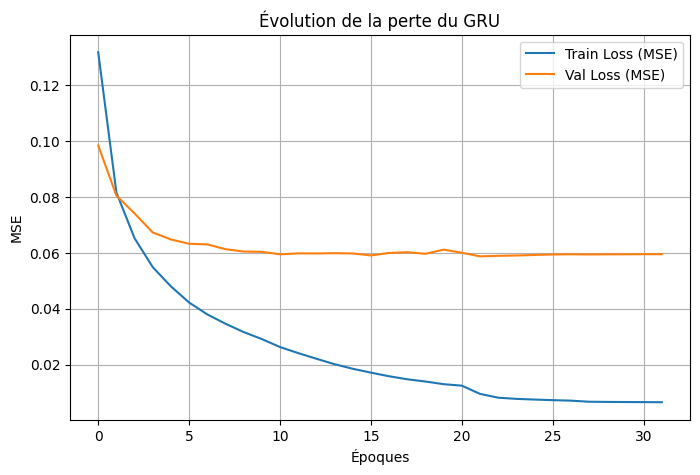

In [14]:
import matplotlib.pyplot as plt

def plot_training_results(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss (MSE)')
    plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
    plt.title('Évolution de la perte du GRU')
    plt.xlabel('Époques')
    plt.ylabel('MSE')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_results(history_gru)

### **3) - Évaluation du modèle GRU**

In [15]:
import numpy as np
from sklearn.metrics import classification_report

def evaluate_gru_metrics(df_test, X_test, model_gru, model_full, window_size=4):
    """
    Calcule les métriques en s'assurant que y_true correspond exactement aux séquences de X_test.
    """
    y_test_true = []

    for seq_id, group in df_test.groupby('seq_id'):
        group = group.sort_values(by='filename', key=lambda x: x.map(natural_keys))
        labels = group['label'].values

        if len(labels) > window_size:
            y_test_true.extend(labels[window_size:])

    y_test_true = np.array(y_test_true).astype(int)

    # Prédiction des vecteurs latents par le GRU
    print(f"Prédiction sur {len(X_test)} séquences...")
    gru_predicted_vectors = model_gru.predict(X_test, verbose=0)

    # Passage dans la tête de classification (dernière couche du CNN) pour transformer le vecteur de 256 en probabilités
    classifier_layer = model_full.layers[-1]
    y_pred_probs = classifier_layer(gru_predicted_vectors)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)


    unique_labels = np.unique(y_test_true)
    target_names = [f"Classe {i}" for i in unique_labels]

    print("\n" + "="*60)
    print("RAPPORT DE CLASSIFICATION : PRÉDICTION DU FUTUR (t+1)")
    print("="*60)
    print(classification_report(y_test_true, y_pred_classes, target_names=target_names, digits=4))

    return y_test_true, y_pred_classes


y_true, y_pred = evaluate_gru_metrics(test_df, X_test, model_prediction, full_model, window_size=4)

Prédiction sur 109 séquences...

RAPPORT DE CLASSIFICATION : PRÉDICTION DU FUTUR (t+1)
              precision    recall  f1-score   support

    Classe 0     0.0000    0.0000    0.0000         8
    Classe 1     0.5938    0.9500    0.7308        20
    Classe 2     0.4839    0.7143    0.5769        21
    Classe 3     1.0000    0.0556    0.1053        18
    Classe 4     0.6667    0.2105    0.3200        19
    Classe 5     0.5641    0.9565    0.7097        23

    accuracy                         0.5596       109
   macro avg     0.5514    0.4811    0.4071       109
weighted avg     0.6025    0.5596    0.4681       109



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


L'analyse du rapport de classification révèle une performance globale modérée avec une accuracy de **56%**, mais souligne surtout une forte hétérogénéité dans la reconnaissance des différents gestes. On observe des disparités critiques : alors que les Classes 1 et 5 affichent d'excellents scores de rappel **(95%)**, indiquant que le modèle parvient à identifier la quasi-totalité de ces gestes, la Classe 0 subit un échec total avec des scores nuls, suggérant une confusion sévère ou une incapacité du modèle à extraire des traits discriminants pour l'absence de doigts levés. Un phénomène de sur-spécialisation apparaît pour la Classe 3 : malgré une précision parfaite **(100%)**, son rappel dérisoire **(5,5%)** prouve que le modèle est extrêmement sélectif, ne classant en "3" que les exemples dont il est absolument certain au détriment de la majorité des autres. Ces résultats, caractérisés par un F1-score macro de **0,40**, mettent en évidence un modèle encore instable qui nécessite un rééquilibrage des données ou une augmentation de la capacité d'apprentissage du GRU pour mieux distinguer les transitions complexes entre les classes intermédiaires.

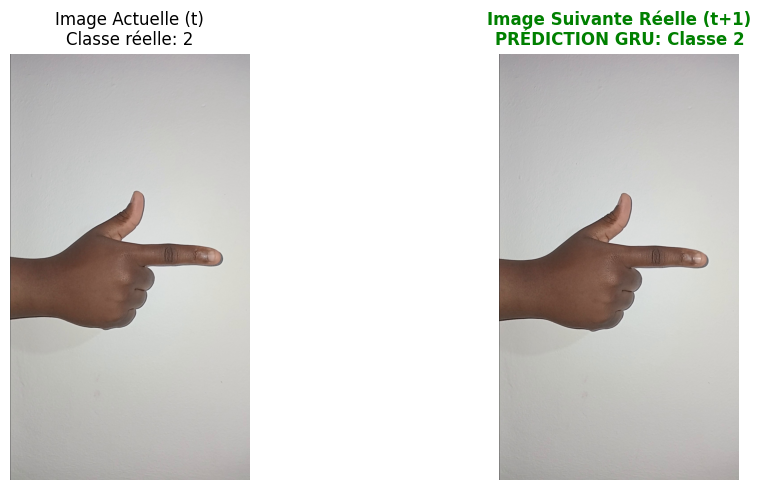

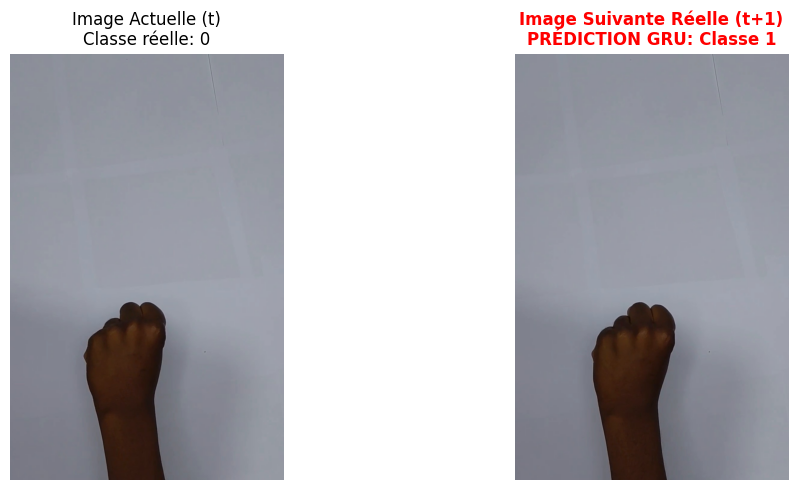

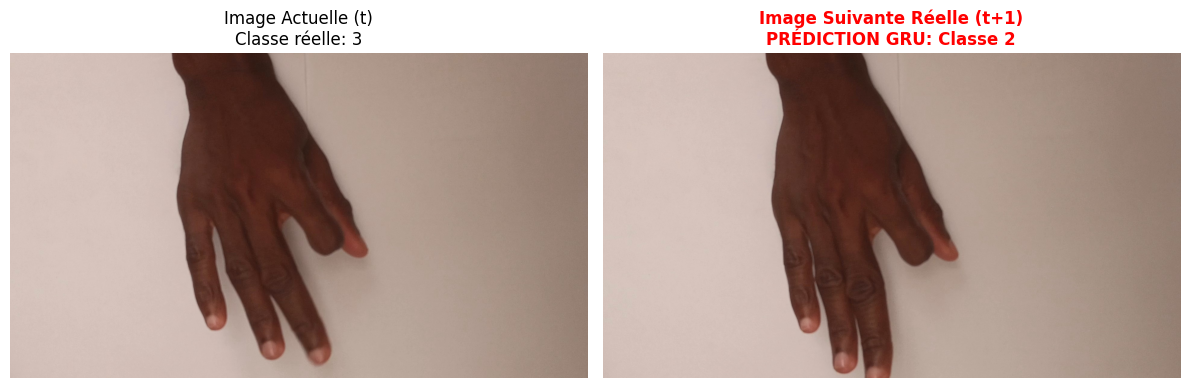

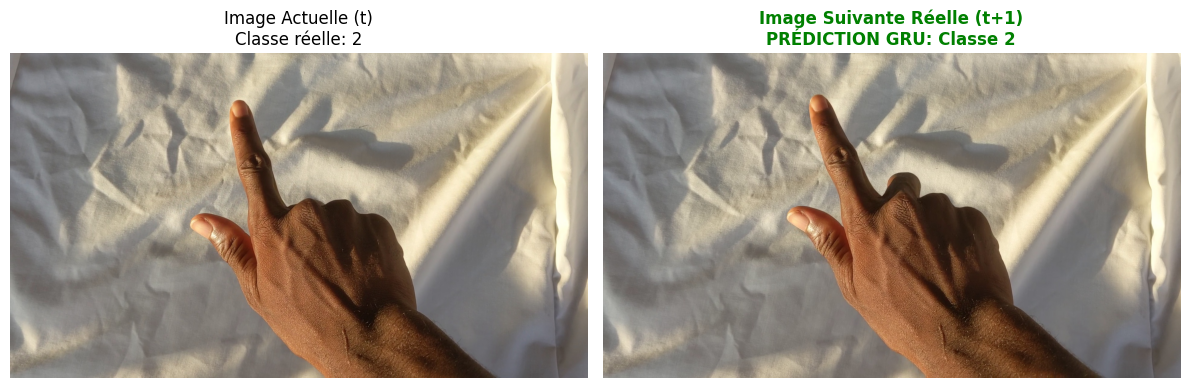

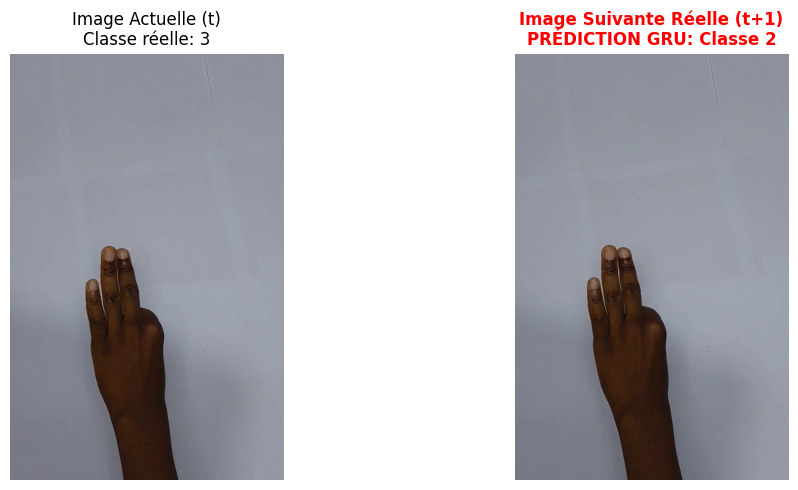

In [16]:
import matplotlib.pyplot as plt
import cv2

def visual_evaluation_gru(df_test, X_test, y_true, y_pred, n_samples=3):
    """
    Affiche l'image actuelle (t), l'image suivante réelle (t+1)
    et la prédiction faite par le GRU.
    """
    test_paths = []
    for seq_id, group in df_test.groupby('seq_id'):
        group = group.sort_values(by='filename', key=lambda x: x.map(natural_keys))
        if len(group) > 4:
            test_paths.append((group['filename'].values[3], group['filename'].values[4]))


    indices = np.random.choice(len(X_test), n_samples, replace=False)

    for idx in indices:
        path_t, path_t_next = test_paths[idx]

        img_t = cv2.cvtColor(cv2.imread(path_t), cv2.COLOR_BGR2RGB)
        img_t_next = cv2.cvtColor(cv2.imread(path_t_next), cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 5))

        # Affichage Image Actuelle (t)
        plt.subplot(1, 2, 1)
        plt.imshow(img_t)
        plt.title(f"Image Actuelle (t)\nClasse réelle: {y_true[idx] if idx < len(y_true) else '?'}")
        plt.axis('off')

        # Affichage Image Suivante (t+1)
        plt.subplot(1, 2, 2)
        plt.imshow(img_t_next)

        # Couleur : Vert si succès, Rouge si erreur
        color = 'green' if y_pred[idx] == y_true[idx] else 'red'

        plt.title(f"Image Suivante Réelle (t+1)\nPRÉDICTION GRU: Classe {y_pred[idx]}",
                  color=color, fontweight='bold')
        plt.axis('off')

        plt.tight_layout()
        plt.show()


visual_evaluation_gru(test_df, X_test, y_true, y_pred, n_samples=5)

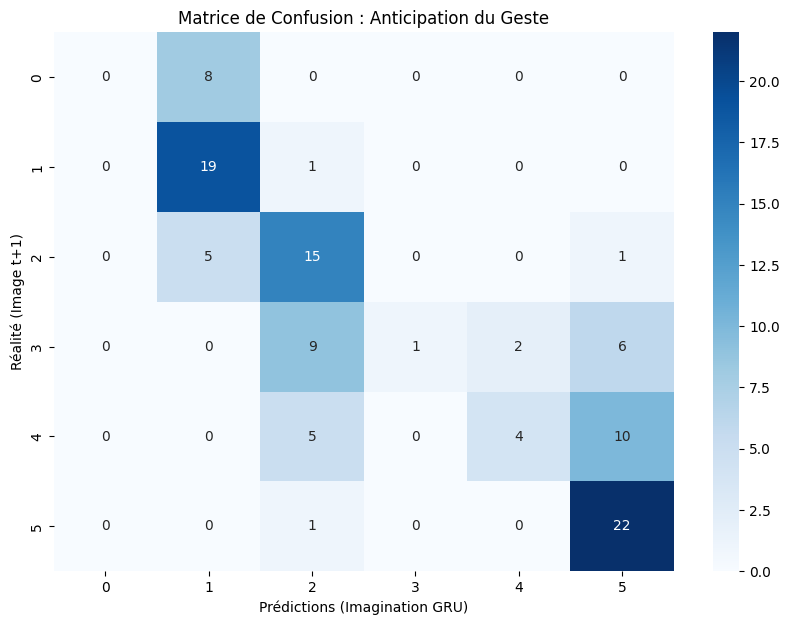

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédictions (Imagination GRU)')
plt.ylabel('Réalité (Image t+1)')
plt.title('Matrice de Confusion : Anticipation du Geste')
plt.show()

L'analyse approfondie de ce rapport de classification confirme que la principale limite du modèle réside dans un déséquilibre marqué des données.

En observant le support, on constate que les classes dominantes (comme la Classe 5 avec 23 échantillons) captent l'essentiel de l'attention du modèle, au détriment des classes minoritaires comme la Classe 0 (seulement 8 échantillons). Ce déséquilibre induit un biais algorithmique : le réseau minimise sa perte globale en se spécialisant sur les gestes les plus fréquents, ce qui explique pourquoi la Classe 0 affiche des scores nuls et pourquoi la Classe 3, malgré sa précision, est presque systématiquement ignorée (rappel de 5%).

Le modèle a ainsi tendance à prédire les classes "majoritaires" par défaut, augmentant artificiellement l'accuracy globale tout en dégradant le F1-score macro, reflet réel de la capacité du système à généraliser sur l'ensemble du dataset de gestes.

# **III - EXPÉRIMENTATION SUR DIFFÉRENTES COUCHES DE CNN**

Le Générateur de Séquences qui lit le DataFrame, groupe par seq_id, et crée les blocs de 4 images pour pouvoir faire les expérimentations.

In [27]:
from tensorflow.keras.utils import Sequence
import cv2
import numpy as np

class GestureSequenceGenerator(Sequence):
    def __init__(self, df, batch_size=8, n_frames=4, input_size=(224, 224)):
        self.df = df
        self.batch_size = batch_size
        self.n_frames = n_frames
        self.input_size = input_size

        self.sequences = []
        for seq_id, group in self.df.groupby('seq_id'):
            group = group.sort_values(by='filename', key=lambda x: x.map(natural_keys))
            for i in range(len(group) - (self.n_frames - 1)):
                self.sequences.append({
                    'paths': group['filename'].values[i:i+self.n_frames],
                    'label': group['label'].values[i+self.n_frames-1]
                })
        self.indices = np.arange(len(self.sequences))

    def __len__(self):
        return int(len(self.indices) // self.batch_size)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        X = []
        Y = []

        for i in batch_indices:
            seq_data = self.sequences[i]
            frames = []
            for p in seq_data['paths']:
                img = cv2.imread(p)
                img = cv2.resize(img, self.input_size) / 255.0
                frames.append(img)

            X.append(frames)
            Y.append(seq_data['label'])

        return np.array(X), np.array(Y)

### Entrainement en fonction des couches gelées du CNN

Il ne s'applique pas à l'ensemble du modèle MobileNetV2 (qui contient 154 couches), mais uniquement aux blocs supérieurs que l'on a décidé d'affiner (fine-tuning).

In [ ]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

def build_experiment_model(freeze_percentage, input_shape=(224, 224, 3), gru_units=512):
    # 1. Chargement du CNN de base
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # 2. Gestion du Fine-Tuning
    num_layers = len(base_model.layers)
    num_to_freeze = int(num_layers * freeze_percentage)

    base_model.trainable = True
    for layer in base_model.layers[:num_to_freeze]:
        layer.trainable = False

    # 3. Définition de l'entrée (Séquence de 4 images)
    model_input = layers.Input(shape=(4, 224, 224, 3), name="sequence_input")

    # 4. Branche Spatiale (CNN)
    x = layers.TimeDistributed(base_model)(model_input)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D())(x)
    x = layers.TimeDistributed(layers.Dense(256, activation='relu'))(x)

    # 5. Branche Temporelle (RNN)
    x = layers.GRU(gru_units, return_sequences=False, name="temporal_analysis")(x)
    x = layers.Dense(256, activation='relu')(x)

    # Sortie (6 classes : de 0 à 5)
    output = layers.Dense(6, activation='softmax')(x)

    full_model = models.Model(inputs=model_input, outputs=output)

    return full_model, num_layers - num_to_freeze

# --- CONFIGURATION DE L'EXPÉRIENCE ---
percentages = [0.9, 0.7, 0.5, 0.3, 0.0]
stats = []

# Utilisation de ton générateur 5D personnalisé
train_gen = GestureSequenceGenerator(train_df, batch_size=16)
valid_gen = GestureSequenceGenerator(val_df, batch_size=16)

for p in percentages:
    print(f"\n🚀 TEST : {int(p*100)}% des couches gelées")

    # Nettoyage de la mémoire pour chaque itération
    tf.keras.backend.clear_session()

    model, trainable_count = build_experiment_model(p)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start = time.time()
    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=3,
        verbose=1
    )
    end = time.time()

    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])

    stats.append({
        "Configuration": f"{int(p*100)}% Gelé",
        "Couches Actives": trainable_count,
        "Accuracy Max": round(val_acc, 4),
        "Loss Min": round(val_loss, 4),
        "Temps (sec)": round(end - start, 2)
    })

# --- RÉSULTATS ---
df_results = pd.DataFrame(stats)
display(df_results)


🚀 TEST : 90% des couches gelées


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 268s 4s/step - accuracy: 0.4677 - loss: 1.2351 - val_accuracy: 0.2404 - val_loss: 2.9092
Epoch 2/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 238s 4s/step - accuracy: 0.6895 - loss: 0.7246 - val_accuracy: 0.1779 - val_loss: 5.7561
Epoch 3/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.8226 - loss: 0.4494 - val_accuracy: 0.2404 - val_loss: 3.8337

🚀 TEST : 70% des couches gelées
Epoch 1/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 304s 4s/step - accuracy: 0.4778 - loss: 1.2593 - val_accuracy: 0.1827 - val_loss: 4.2198
Epoch 2/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 262s 4s/step - accuracy: 0.6966 - loss: 0.7771 - val_accuracy: 0.1779 - val_loss: 3.1566
Epoch 3/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.7933 - loss: 0.5693 - val_accuracy: 0.2404 - val_loss: 2.0588

🚀 TEST : 50% des couches gelées
Epoch 1/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 362s 5s/step - accuracy: 0.4254 - loss: 1.3138 - val_accuracy: 0.2548 - val_loss: 2.6460
Epoch 2/3
62/62 ━━━━━━━━━━━━━━━━━━━━ 315s 5s/step - 

Ainsi, le meilleur modèle est le modèle avec aucune couche gelée. Pour les autres la val_loss et val_accuracy, sont trop faibles.

# **III - INFÉRENCE**

Il faut exécuter ce code après avoir exécuté toutes les cellules pour inférer.

In [ ]:
import cv2
import numpy as np

def inferer_nouveau_geste(liste_chemins_images, cnn_spatial, gru_temporel):
    """
    Prend 4 chemins d'images, extrait les caractéristiques et prédit le futur.
    """
    if len(liste_chemins_images) != 4:
        print("Erreur : Vous devez fournir exactement 4 images successives.")
        return None

    # 1. Extraction spatiale (CNN)
    # On crée l'extracteur à partir du full_model (avant-dernière couche)
    extractor = tf.keras.Model(inputs=cnn_spatial.input,
                              outputs=cnn_spatial.layers[-2].output)

    features_sequence = []

    for chemin in liste_chemins_images:
        # Lecture et prétraitement
        img = cv2.imread(chemin)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224)) / 255.0
        img = np.expand_dims(img, axis=0) # (1, 224, 224, 3)

        # Extraction du vecteur de caractéristiques
        feat = extractor.predict(img, verbose=0)
        features_sequence.append(feat)

    # 2. Préparation pour le GRU
    # On transforme la liste en tenseur 3D : (1, 4, dimension_features)
    X_input_gru = np.array(features_sequence).reshape(1, 4, -1)

    # 3. Prédiction du vecteur futur par le GRU
    vecteur_futur = gru_temporel.predict(X_input_gru, verbose=0)

    # 4. Classification via la tête du CNN (Dernière couche Dense)
    classifier = cnn_spatial.layers[-1]
    probabilites = classifier(vecteur_futur)

    classe_id = np.argmax(probabilites)
    confiance = np.max(probabilites)

    return classe_id, confiance

# --- EXEMPLE D'UTILISATION ---
nouvelle_sequence = [
    "/content/drive/MyDrive/dataset_final2/AA/001_01_0.jpg",
    "/content/drive/MyDrive/dataset_final2/AA/001_02_0.jpg",
    "/content/drive/MyDrive/dataset_final2/AA/001_03_0.jpg",
    "/content/drive/MyDrive/dataset_final2/AA/001_04_0.jpg"
]

classe, score = inferer_nouveau_geste(nouvelle_sequence, full_model, model_prediction)

noms_classes = ["Geste 0", "Geste 1", "Geste 2", "Geste 3", "Geste 4", "Geste 5"]
print(f"🔮 Résultat de l'inférence : {noms_classes[classe]} (Confiance : {score*100:.2f}%)")